<a href="https://colab.research.google.com/github/thaoS2/BI_Nhom7_BT/blob/main/Homework/HW05_Portfolio_VaR/notebook/04_monte_carlo_var_es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHƯƠNG 5. MÔ PHỎNG MONTE CARLO VÀ ƯỚC TÍNH VaR, ES

## 5.1. Phương pháp luận Monte Carlo

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/content")
DATA_PATH = "../data/processed_portfolio_2023_2024.csv"
WEIGHTS_PATH ="../data/portfolio_weights.csv"
COV_PATH ="../data/covariance_matrix.csv"
OUT_DIR = "../outputs"
FIG_DIR = "../figures"

required_files = [DATA_PATH, WEIGHTS_PATH, COV_PATH]
missing_files = [str(p) for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        """Không tìm thấy các file đầu vào sau:
- """ + "\n- ".join(missing_files))

returns = pd.read_csv(DATA_PATH, parse_dates=["Date"])
assets = ["BTC", "GLD", "SPY"]
asset_cols = ["BTC_Return", "GLD_Return", "SPY_Return"]

missing_cols = [c for c in ["Date", *asset_cols] if c not in returns.columns]
if missing_cols:
    raise ValueError(f"Thiếu cột trong processed data: {missing_cols}")

returns = returns.dropna(subset=asset_cols).copy()

weights_table = pd.read_csv(WEIGHTS_PATH)
if "Chosen" not in weights_table.columns:
    raise ValueError("portfolio_weights.csv phải có cột 'Chosen'.")

chosen_mask = (
    weights_table["Chosen"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes"])
)

if chosen_mask.sum() != 1:
    raise ValueError(
        f"Cần đúng 1 dòng Chosen = True trong portfolio_weights.csv, hiện có {chosen_mask.sum()} dòng."
    )

chosen = weights_table.loc[chosen_mask].iloc[0]
weights = chosen[assets].astype(float).to_numpy()

if not np.isclose(weights.sum(), 1.0, atol=1e-6):
    raise ValueError(f"Tổng tỷ trọng phải bằng 1, hiện tại = {weights.sum():.6f}")

cov_matrix = pd.read_csv(COV_PATH, index_col=0)
cov_matrix = cov_matrix.loc[assets, assets].astype(float)

mean_returns = returns[asset_cols].mean().to_numpy()

cov_recomputed = returns[asset_cols].cov()
cov_recomputed.index = assets
cov_recomputed.columns = assets
covariance_matches_chapter_4 = np.allclose(
    cov_recomputed.to_numpy(),
    cov_matrix.to_numpy(),
    rtol=1e-5,
    atol=1e-10
)

print("Số quan sát:", len(returns))
print("Phương án danh mục:", chosen.iloc[0])
print("Tỷ trọng:", dict(zip(assets, weights)))
print("Covariance matrix khớp Chương 4:", covariance_matches_chapter_4)
display(returns.head())

Số quan sát: 501
Phương án danh mục: Equal Weight
Tỷ trọng: {'BTC': np.float64(0.333333), 'GLD': np.float64(0.333333), 'SPY': np.float64(0.333333)}
Covariance matrix khớp Chương 4: True


,Date,BTC_Return,GLD_Return,SPY_Return
0,2023-01-04,0.010934,0.009368,0.007691
1,2023-01-05,-0.001573,-0.012530,-0.011479
2,2023-01-06,0.006821,0.018535,0.022673
3,2023-01-09,0.014325,0.002243,-0.000567
4,2023-01-10,0.014418,0.003669,0.006989


## 5.2. Thiết lập thông số mô phỏng

- Số lần mô phỏng: **10.000**
- Mức tin cậy: **95%**
- Khoảng thời gian rủi ro: **1 ngày**
- Random seed: **42**
- Tỷ trọng: kế thừa trực tiếp từ Chương 3.


In [7]:
N_SIMULATIONS = 10_000
CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL
RANDOM_SEED = 42
HORIZON_DAYS = 1

portfolio_mean = float(weights @ mean_returns)
portfolio_variance = float(weights @ cov_matrix.to_numpy() @ weights)
portfolio_volatility = float(np.sqrt(portfolio_variance))

print(f"Historical expected return/day: {portfolio_mean:.6%}")
print(f"Historical volatility/day: {portfolio_volatility:.6%}")

Historical expected return/day: 0.168291%
Historical volatility/day: 1.250378%


## 5.3. Phân phối tỷ suất sinh lợi mô phỏng


In [8]:
np.random.seed(RANDOM_SEED)

simulated_asset_returns = np.random.multivariate_normal(
    mean=mean_returns,
    cov=cov_matrix.to_numpy(),
    size=N_SIMULATIONS
)

simulated_portfolio_returns = simulated_asset_returns @ weights

simulated_df = pd.DataFrame(
    simulated_asset_returns,
    columns=["BTC_Sim_Return", "GLD_Sim_Return", "SPY_Sim_Return"]
)
simulated_df["Portfolio_Sim_Return"] = simulated_portfolio_returns
simulated_df.to_csv(OUTPUT_DIR / "simulated_returns.csv", index=False)

summary = simulated_df["Portfolio_Sim_Return"].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
)
display(summary.to_frame(name="Portfolio_Sim_Return"))

,Portfolio_Sim_Return
count,10000.000000
mean,0.001743
std,0.012534
min,-0.054080
1%,-0.027086
5%,-0.018918
50%,0.001653
95%,0.022469
99%,0.030786
max,0.047910


## 5.4. Tính VaR 95%

VaR 95% được xác định từ phân vị 5% của phân phối lợi nhuận danh mục mô phỏng. Kết quả được trình bày dưới dạng mức tổn thất dương.


In [9]:
q05 = float(np.quantile(simulated_portfolio_returns, ALPHA))
var_95 = float(-q05)

print(f"5th percentile return threshold: {q05:.6%}")
print(f"VaR 95% (1-day): {var_95:.6%}")

5th percentile return threshold: -1.891779%
VaR 95% (1-day): 1.891779%


## 5.5. Tính Expected Shortfall (ES) 95%

ES 95% là mức tổn thất trung bình của những kịch bản nằm trong 5% trường hợp xấu nhất, tức các lợi nhuận nhỏ hơn hoặc bằng ngưỡng VaR.


In [10]:
tail_returns = simulated_portfolio_returns[simulated_portfolio_returns <= q05]
es_95 = float(-tail_returns.mean())

print(f"Số kịch bản trong đuôi 5%: {len(tail_returns)}")
print(f"ES 95% (1-day): {es_95:.6%}")

Số kịch bản trong đuôi 5%: 500
ES 95% (1-day): 2.401038%


## Tổng hợp và lưu kết quả


In [11]:
simulation_parameters = pd.DataFrame({
    "Parameter": [
        "Historical_Observations",
        "Portfolio_Method",
        "BTC_Weight",
        "GLD_Weight",
        "SPY_Weight",
        "N_Simulations",
        "Confidence_Level",
        "Horizon_Days",
        "Random_Seed",
        "Historical_Portfolio_Mean_Daily",
        "Historical_Portfolio_Volatility_Daily",
        "Covariance_Matrix_Matches_Chapter_4"
    ],
    "Value": [
        len(returns),
        chosen.iloc[0],
        weights[0],
        weights[1],
        weights[2],
        N_SIMULATIONS,
        CONFIDENCE_LEVEL,
        HORIZON_DAYS,
        RANDOM_SEED,
        portfolio_mean,
        portfolio_volatility,
        covariance_matches_chapter_4
    ]
})

simulation_parameters.to_csv(
    OUTPUT_DIR / "simulation_parameters.csv",
    index=False
)

results = pd.DataFrame({
    "Metric": [
        "Simulated Mean Daily Return",
        "Simulated Daily Volatility",
        "5th Percentile Return Threshold",
        "VaR 95% (1-day)",
        "ES 95% (1-day)",
        "Tail Scenario Count"
    ],
    "Value": [
        simulated_portfolio_returns.mean(),
        simulated_portfolio_returns.std(ddof=1),
        q05,
        var_95,
        es_95,
        len(tail_returns)
    ]
})

results["Value_Percent"] = [
    simulated_portfolio_returns.mean() * 100,
    simulated_portfolio_returns.std(ddof=1) * 100,
    q05 * 100,
    var_95 * 100,
    es_95 * 100,
    np.nan
]

results.to_csv(OUTPUT_DIR / "var_es_results.csv", index=False)

display(simulation_parameters)
display(results)

,Parameter,Value
0,Historical_Observations,501
1,Portfolio_Method,Equal Weight
2,BTC_Weight,0.333333
3,GLD_Weight,0.333333
4,SPY_Weight,0.333333
5,N_Simulations,10000
6,Confidence_Level,0.95
7,Horizon_Days,1
8,Random_Seed,42
9,Historical_Portfolio_Mean_Daily,0.001683


,Metric,Value,Value_Percent
0,Simulated Mean Daily Return,0.001743,0.174327
1,Simulated Daily Volatility,0.012534,1.253371
2,5th Percentile Return Threshold,-0.018918,-1.891779
3,VaR 95% (1-day),0.018918,1.891779
4,ES 95% (1-day),0.024010,2.401038
5,Tail Scenario Count,500.000000,NaN


## Hình 5.1. Phân phối lợi nhuận danh mục từ Monte Carlo


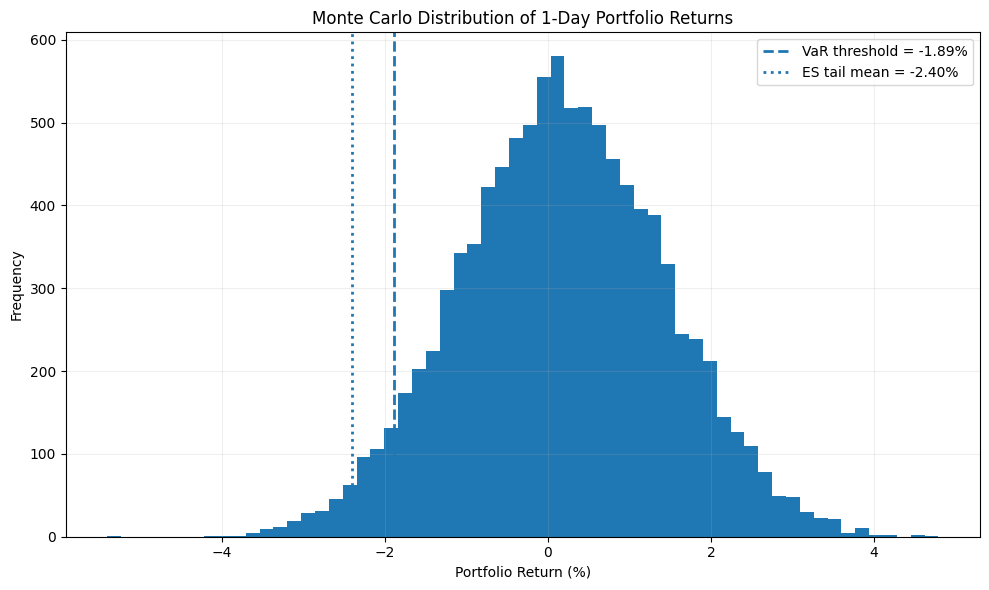

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(simulated_portfolio_returns * 100, bins=60)
ax.axvline(q05 * 100, linestyle="--", linewidth=2,
           label=f"VaR threshold = {q05*100:.2f}%")
ax.axvline(-es_95 * 100, linestyle=":", linewidth=2,
           label=f"ES tail mean = {-es_95*100:.2f}%")
ax.set_title("Monte Carlo Distribution of 1-Day Portfolio Returns")
ax.set_xlabel("Portfolio Return (%)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "monte_carlo_distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Kiểm tra file đầu ra


In [13]:
expected_outputs = [
    OUTPUT_DIR / "simulation_parameters.csv",
    OUTPUT_DIR / "simulated_returns.csv",
    OUTPUT_DIR / "var_es_results.csv",
    FIGURE_DIR / "monte_carlo_distribution.png"
]

for p in expected_outputs:
    print(("✓" if p.exists() else "✗"), p)

✓ /content/simulation_parameters.csv
✓ /content/simulated_returns.csv
✓ /content/var_es_results.csv
✓ /content/monte_carlo_distribution.png
